### Analysis Overview

- Compares **tissue contributions** between **AD** and **NCI** cohorts for each **deconvolution tool**.  
- Uses **Mann–Whitney U tests** to assess cohort differences within each tool.  
- Produces **boxplots with jittered points** showing AD and NCI distributions side by side.  
- Adds **significance brackets and p-value stars** above each pair (based on raw p-values).  
- Saves both **plots (PNG/PDF)** and **statistical summaries (CSV)** for each tissue.


Loaded 1694 samples across 7 tools.

=== Brain ===
  DeconvolutionTool      pval  BH_adj_p  Significant
0        BayesPrism  0.035951  0.035951         True
1             MuSiC  0.655080  0.655080        False
2             nuSVR  0.053250  0.053250        False
3        CIBERSORTx  0.222162  0.222162        False
4              NNLS  0.511486  0.511486        False
5                QP  0.391627  0.391627        False
6          ReDeconv  0.010175  0.010175         True


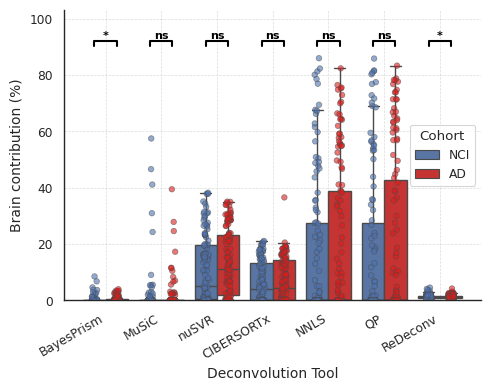


=== NerveTibial ===
  DeconvolutionTool      pval  BH_adj_p  Significant
0        BayesPrism  0.000068  0.000068         True
1             MuSiC  0.798261  0.798261        False
2             nuSVR  0.083813  0.083813        False
3        CIBERSORTx  0.004407  0.004407         True
4              NNLS  0.498423  0.498423        False
5                QP  0.455222  0.455222        False
6          ReDeconv  0.002312  0.002312         True


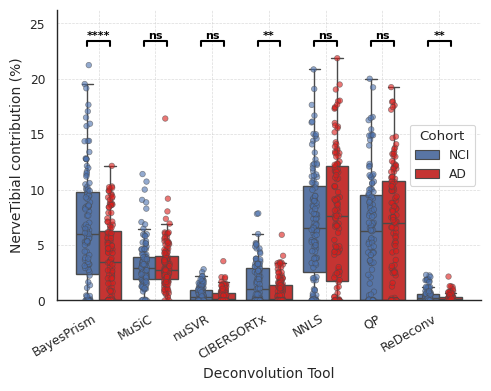


=== Arteries ===
  DeconvolutionTool      pval  BH_adj_p  Significant
0        BayesPrism  0.000052  0.000052         True
1             MuSiC  0.000003  0.000003         True
2             nuSVR  0.003379  0.003379         True
3        CIBERSORTx  0.004452  0.004452         True
4              NNLS  0.830320  0.830320        False
5                QP  0.703249  0.703249        False
6          ReDeconv  0.000201  0.000201         True


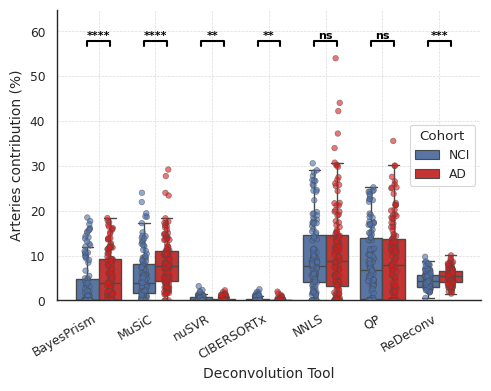

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# ---------- Helper functions ----------
def pval_to_star(p):
    """Convert p-value to significance stars."""
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# ---------- User parameters ----------
tissues_of_interest = ["Brain", "NerveTibial", "Arteries"]
tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
palette = {"NCI": "#4C72B0", "AD": "#DD1C1A"}

# ---------- Load data ----------
files = {
    "NCI": "Decon-Results_Toden_NCI/merged_normalised_results.txt",
    "AD": "Decon-Results_Toden_AD/merged_normalised_results.txt"
}

dfs = []
for cohort, path in files.items():
    df = pd.read_csv(path, sep="\t", index_col=0)
    df["Cohort"] = cohort
    dfs.append(df)

merged = pd.concat(dfs)
print(f"Loaded {merged.shape[0]} samples across {merged['DeconvolutionTool'].nunique()} tools.")

# ---------- Long format ----------
long_df = merged.melt(
    id_vars=["DeconvolutionTool", "Cohort"],
    var_name="Tissue",
    value_name="Contribution"
)

# Keep only tissues of interest
long_df = long_df[long_df["Tissue"].isin(tissues_of_interest)]

# ---------- Plot + stats ----------

for tissue in tissues_of_interest:
    df_t = long_df[long_df["Tissue"] == tissue].copy()

    # --- Statistical testing ---
    results = []
    for tool, df_tool in df_t.groupby("DeconvolutionTool"):
        groups = df_tool.groupby("Cohort")["Contribution"].apply(list)
        if set(groups.keys()) == {"NCI", "AD"}:
            stat, pval = mannwhitneyu(groups["NCI"], groups["AD"], alternative="two-sided")
            results.append({"DeconvolutionTool": tool, "pval": pval})

    results_df = pd.DataFrame(results)
    
    # No multiple-testing correction; stars from raw p-values
    if not results_df.empty:
        reject, pvals_corrected, _, _ = multipletests(results_df["pval"], method="fdr_bh")
        results_df["BH_adj_p"] = results_df["pval"]  # keep raw p-values
        results_df["Significant"] = results_df["pval"] < 0.05
    else:
        results_df = pd.DataFrame(columns=["DeconvolutionTool", "pval", "BH_adj_p", "Significant"])

    results_df = results_df.set_index("DeconvolutionTool").reindex(tool_order).reset_index()
    print(f"\n=== {tissue} ===")
    print(results_df)

    # --- Plot ---
    plt.figure(figsize=(5, 4))
    sns.set_theme(style="white")
    sns.set_context("paper", font_scale=1.0)

    ax = sns.boxplot(
        data=df_t,
        x="DeconvolutionTool",
        y="Contribution",
        hue="Cohort",
        order=tool_order,
        palette=palette,
        dodge=True,
        showfliers=False
    )

    sns.stripplot(
        data=df_t,
        x="DeconvolutionTool",
        y="Contribution",
        hue="Cohort",
        order=tool_order,
        palette=palette,
        dodge=True,
        jitter=True,
        alpha=0.6,
        linewidth=0.5,
        size=4
    )

    # Remove duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title="Cohort")

    # Get positions for bracket annotations
    xticks = ax.get_xticks()
    xticklabels = [t.get_text() for t in ax.get_xticklabels()]
    tool_to_x = dict(zip(xticklabels, xticks))
    ymax = df_t["Contribution"].max()

    # Draw bracket function
    def add_bracket(ax, x1, x2, y, text, height=0.05):
        ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], lw=1.5, c='black')
        ax.text((x1+x2)/2, y+height, text, ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='black')

    # Annotate with significance stars
    for _, row in results_df.iterrows():
        tool = row["DeconvolutionTool"]
        if pd.notna(row["BH_adj_p"]) and tool in tool_to_x:
            x = tool_to_x[tool]
            pval = row["BH_adj_p"]
            label = pval_to_star(pval)
            offset = 0.2
            x1, x2 = x - offset, x + offset
            y = ymax * 1.05
            add_bracket(ax, x1, x2, y, label, height=ymax * 0.02)

    ax.set_xlabel("Deconvolution Tool", fontsize=10)
    ax.set_ylabel(f"{tissue} contribution (%)", fontsize=10)
    ax.set_ylim(0, ymax * 1.2)
    #ax.set_title(f"{tissue} contribution across cohorts", fontsize=16, fontweight="bold")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    sns.despine()
    plt.tight_layout()
    plt.savefig(f"{tissue}_AD_vs_NCI_boxplot.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{tissue}_AD_vs_NCI_boxplot.svg", format="svg", bbox_inches="tight")
    plt.show()

    # Save stats
    results_df.to_csv(f"{tissue}_AD_vs_NCI_stats.csv", index=False)
